# CO2RR-to-CO discovery pipeline — end-to-end summary (main figure)

One-page synthesis of the full economic high-entropy carbide (HEC) discovery campaign:
**generate -> cheap-screen -> fairchem ΔG_CO -> top-6 -> QE bulk validation (+PDOS)**.
Pulls the artifacts produced by the per-stage notebooks (12, 19, 18, 16, 20) and builds the
master table + a 4-panel composite figure. **Re-runnable** — reads whatever each stage has written.


In [6]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

ROOT = Path('/home/jonglee69/mattergen/CarbideMatterGen'); sys.path.insert(0, str(ROOT))
GEN = ROOT/'outputs'/'gen_co2rr_economic'; SCREEN = ROOT/'outputs'/'screen_co2rr'
QE = ROOT/'outputs'/'qe'; SQS = ROOT/'outputs'/'sqs'; FIG = ROOT/'figures'; FIG.mkdir(exist_ok=True)
CO_OPT, CO_WINDOW = 0.0, 0.20
NATURE_RC = {'font.family':'sans-serif','font.sans-serif':['Arial','DejaVu Sans'],
    'font.size':8,'axes.labelsize':8,'axes.titlesize':9,'xtick.labelsize':7,'ytick.labelsize':7,
    'legend.fontsize':6,'axes.linewidth':0.6,'xtick.direction':'in','ytick.direction':'in',
    'legend.frameon':False,'pdf.fonttype':42,'savefig.bbox':'tight','savefig.dpi':300}
mpl.rcParams.update(NATURE_RC)
OI = {'blue':'#0072B2','vermil':'#D55E00','green':'#009E73','orange':'#E69F00','sky':'#56B4E9','purple':'#CC79A7','gray':'#888888'}
EL_COL = {'C':'#333333','Y':'#0072B2','Zr':'#56B4E9','W':'#D55E00','Ce':'#009E73','La':'#CC79A7','Pr':'#E69F00','Nd':'#F0E442','Hf':'#999999','Zn':'#8C564B','Ti':'#17BECF','Sc':'#BCBD22'}

# --- stage artifacts ---
n_gen = len(list(GEN.rglob('*.cif')))
top_co = pd.read_csv(GEN/'top_CO.csv') if (GEN/'top_CO.csv').exists() else pd.DataFrame()
n_cheap = top_co['formula'].nunique() if len(top_co) else 0
screen = [json.loads(l) for l in (SCREEN/'co2rr.jsonl').read_text().splitlines()] if (SCREEN/'co2rr.jsonl').exists() else []
n_fair = len([r for r in screen if 'error' not in r])
top6 = pd.read_csv(SCREEN/'top6.csv') if (SCREEN/'top6.csv').exists() else pd.DataFrame()
qev = pd.read_csv(QE/'qe_validation_summary.csv') if (QE/'qe_validation_summary.csv').exists() else pd.DataFrame()
pdos = pd.read_csv(QE/'qe_pdos_Ef_contributions.csv') if (QE/'qe_pdos_Ef_contributions.csv').exists() else pd.DataFrame()
sqs = pd.read_csv(SQS/'sqs_summary.csv') if (SQS/'sqs_summary.csv').exists() else pd.DataFrame()
n_qe_metal = int(qev['metallic'].sum()) if 'metallic' in qev.columns else 0
print('funnel:', dict(generated=n_gen, cheap_econHEC=n_cheap, fairchem=n_fair, top6=len(top6), QE_metallic=n_qe_metal))
print('SQS built:', len(sqs))


funnel: {'generated': 1024, 'cheap_econHEC': 90, 'fairchem': 24, 'top6': 6, 'QE_metallic': 6}
SQS built: 12


## 1. Master summary table (top-6 carried through every stage)


In [7]:
m = top6.copy()
if len(qev): m = m.merge(qev[[c for c in ['formula','E_fermi_eV','dos_at_Ef','metallic','P_kbar'] if c in qev.columns]], on='formula', how='left')
if len(pdos):
    elc = [c for c in pdos.columns if c.startswith('%')]
    def dom(row):
        vals = {c[1:]: row[c] for c in elc if pd.notna(row[c])}
        return max(vals, key=vals.get) if vals else None
    pdos = pdos.assign(dominant=pdos.apply(dom, axis=1))
    m = m.merge(pdos[['formula','DOS_Ef_total','dominant']], on='formula', how='left')
m = m.sort_values('best_dG_CO', key=lambda s: s.abs())
cols = [c for c in ['formula','best_dG_CO','frac_co_selective','co_selective_over_h','E_fermi_eV','dos_at_Ef','metallic','dominant','P_kbar'] if c in m.columns]
m[cols].to_csv(SCREEN/'co2rr_master_summary.csv', index=False)
print(m[cols].to_string(index=False)); print('\nsaved', SCREEN/'co2rr_master_summary.csv')


    formula  best_dG_CO  frac_co_selective  co_selective_over_h  E_fermi_eV  dos_at_Ef  metallic dominant  P_kbar
   Pr3Y2WC6     -0.0009             0.2143                 True     12.0039       7.44      True        C    0.15
  La5Y4W2C9     -0.0012             0.1364                 True     11.5226       9.82      True        C   -0.10
 Ce2Y2ZrWC6      0.0071             0.1071                 True     12.7204       6.71      True        C   -0.29
La3Y5(WC3)3     -0.0081             0.1667                 True     12.2408      12.42      True        Y   -0.32
    Y2ZrWC8     -0.0098             0.1923                 True     10.5208       1.70      True        W    0.41
  CeY2ZrWC7     -0.0111             0.1591                 True     12.8520       3.30      True        C   -0.13

saved /home/jonglee69/mattergen/CarbideMatterGen/outputs/screen_co2rr/co2rr_master_summary.csv


## 2. Composite main figure

(a) discovery funnel; (b) fairchem $\Delta G_{CO}$ of the screened candidates with the top-6
highlighted; (c) QE metallicity — DOS at $E_F$ of the top-6; (d) PDOS conduction character
(per-element share of DOS at $E_F$).


saved fig_co2rr_pipeline_summary


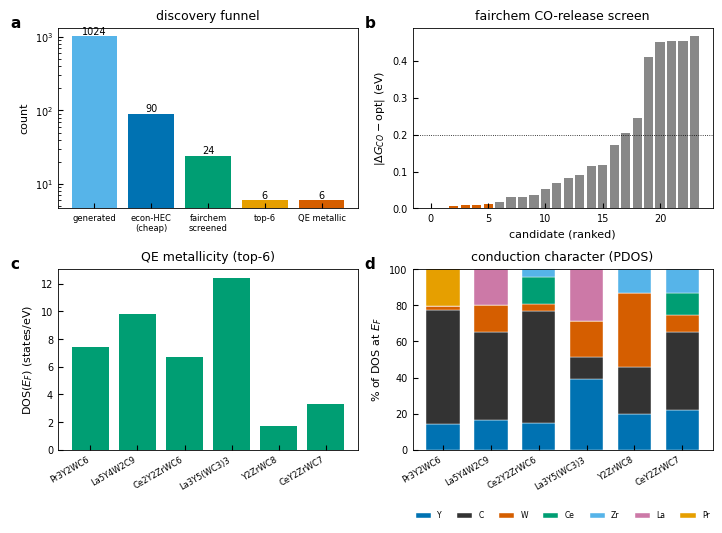

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(7.4, 5.4))
for a, ch in zip(ax.flat, 'abcd'):
    a.text(-0.16, 1.07, ch, transform=a.transAxes, fontsize=11, fontweight='bold', va='top')

# (a) funnel
stages = ['generated','econ-HEC\n(cheap)','fairchem\nscreened','top-6','QE metallic']
vals = [n_gen, n_cheap, n_fair, len(top6), n_qe_metal]
cols_f = [OI['sky'], OI['blue'], OI['green'], OI['orange'], OI['vermil']]
ax[0,0].bar(range(len(stages)), vals, color=cols_f)
for i, v in enumerate(vals): ax[0,0].text(i, v, str(v), ha='center', va='bottom', fontsize=7)
ax[0,0].set_yscale('log'); ax[0,0].set_xticks(range(len(stages))); ax[0,0].set_xticklabels(stages, fontsize=6)
ax[0,0].set_ylabel('count'); ax[0,0].set_title('discovery funnel')

# (b) fairchem dG_CO of all screened, top-6 highlighted
if len(screen):
    sc = pd.DataFrame([{'formula': r['source'].split('__')[0], 'best_dG_CO': r.get('best_dG_CO')} for r in screen if r.get('best_dG_CO') is not None])
    sc = sc.sort_values('best_dG_CO', key=lambda s: s.abs()).reset_index(drop=True)
    t6 = set(top6['formula']) if len(top6) else set()
    colb = [OI['vermil'] if f in t6 else OI['gray'] for f in sc.formula]
    ax[0,1].bar(range(len(sc)), sc.best_dG_CO.abs(), color=colb)
    ax[0,1].axhline(CO_WINDOW, color='k', ls=':', lw=0.6)
    ax[0,1].set_xlabel('candidate (ranked)'); ax[0,1].set_ylabel(r'$|\Delta G_{CO}-\mathrm{opt}|$ (eV)')
    ax[0,1].set_title('fairchem CO-release screen')

# (c) QE DOS(E_F) for top-6 (qev already carries best_dG_CO from notebook 20)
if len(qev) and 'dos_at_Ef' in qev.columns:
    q = qev.dropna(subset=['dos_at_Ef']).copy()
    if 'best_dG_CO' in q.columns: q = q.sort_values('best_dG_CO', key=lambda s: s.abs())
    ax[1,0].bar(range(len(q)), q.dos_at_Ef, color=OI['green'])
    ax[1,0].set_xticks(range(len(q))); ax[1,0].set_xticklabels(q.formula, rotation=30, ha='right', fontsize=6)
    ax[1,0].set_ylabel(r'DOS($E_F$) (states/eV)'); ax[1,0].set_title('QE metallicity (top-6)')

# (d) PDOS conduction character
if len(pdos):
    con = pdos.copy()
    if len(top6):
        order = [f for f in top6['formula'] if f in set(con['formula'])]
        con = con.set_index('formula').reindex(order).reset_index()
    elc = [c for c in con.columns if c.startswith('%')]
    bottom = np.zeros(len(con)); xp = np.arange(len(con))
    for c in elc:
        el=c[1:]; v=con[c].fillna(0).values
        ax[1,1].bar(xp, v, bottom=bottom, color=EL_COL.get(el,'#444'), label=el, width=0.7, edgecolor='white', linewidth=0.3)
        bottom += v
    ax[1,1].set_xticks(xp); ax[1,1].set_xticklabels(con['formula'], rotation=30, ha='right', fontsize=6)
    ax[1,1].set_ylabel('% of DOS at $E_F$'); ax[1,1].set_ylim(0,100); ax[1,1].set_title('conduction character (PDOS)')
    ax[1,1].legend(loc='upper center', bbox_to_anchor=(0.5,-0.30), ncol=min(7,len(elc)), fontsize=5.5)

fig.tight_layout()
for ext in ('pdf','png'): fig.savefig(FIG/f'fig_co2rr_pipeline_summary.{ext}')
print('saved fig_co2rr_pipeline_summary'); plt.show()


## 3. Pipeline narrative

1. **Generate** — the economic-conditioned fine-tuned MatterGen produced ~1k carbides biased to
   CO-releasing, metallic, PGM/heavy-REE-free compositions.
2. **Cheap screen** — composition proxies funnel to economic CO-releasing high-entropy carbides.
3. **fairchem (UMA) surface screen** — real ΔG_CO/COOH/H over all low-index facets ranks the survivors.
4. **Top-6** — best CO-releasing, CO-over-H selective candidates.
5. **QE** — PBE-DFT confirms all six are metallic (finite DOS at $E_F$, low residual stress); PDOS
   resolves the conduction character (C-2p network vs metal-d).
6. **SQS (Stage A')** — solid-solution supercells of the HEC shortlist for explicit-disorder follow-up.

Artifacts: `outputs/screen_co2rr/co2rr_master_summary.csv` + `figures/fig_co2rr_pipeline_summary.*`.
_Re-run to refresh the whole synthesis from the per-stage outputs._


--- 에탄올 생성량과의 상관계수 ---
에탄올 생성량(임의값)                 1.000000
Catalyst powder (g)          0.450973
Ink Concentration (mg/mL)    0.339266
용매 Type_NPA                  0.245998
NPA(alcohol) (g)             0.140398
용매 Type_IPA                 -0.044300
DI water (g)                -0.051484
용매 내의 물 분율(wt%)             -0.051484
IPA(alcohol) (g)            -0.055555
용매 Type_NPA + IPA           -0.185113
5wt% nafion solution (g)    -0.339125
just I/C                    -0.339125
순수 Nafion 질량 (g)            -0.339125
I/C ratio                   -0.339125
총 질량 (g)                    -0.339125
Total Solvent(mL)           -0.339125
Carbon black (g)            -0.450973
Carbon 첨가 비율 (wt%)          -0.450973
Name: 에탄올 생성량(임의값), dtype: float64


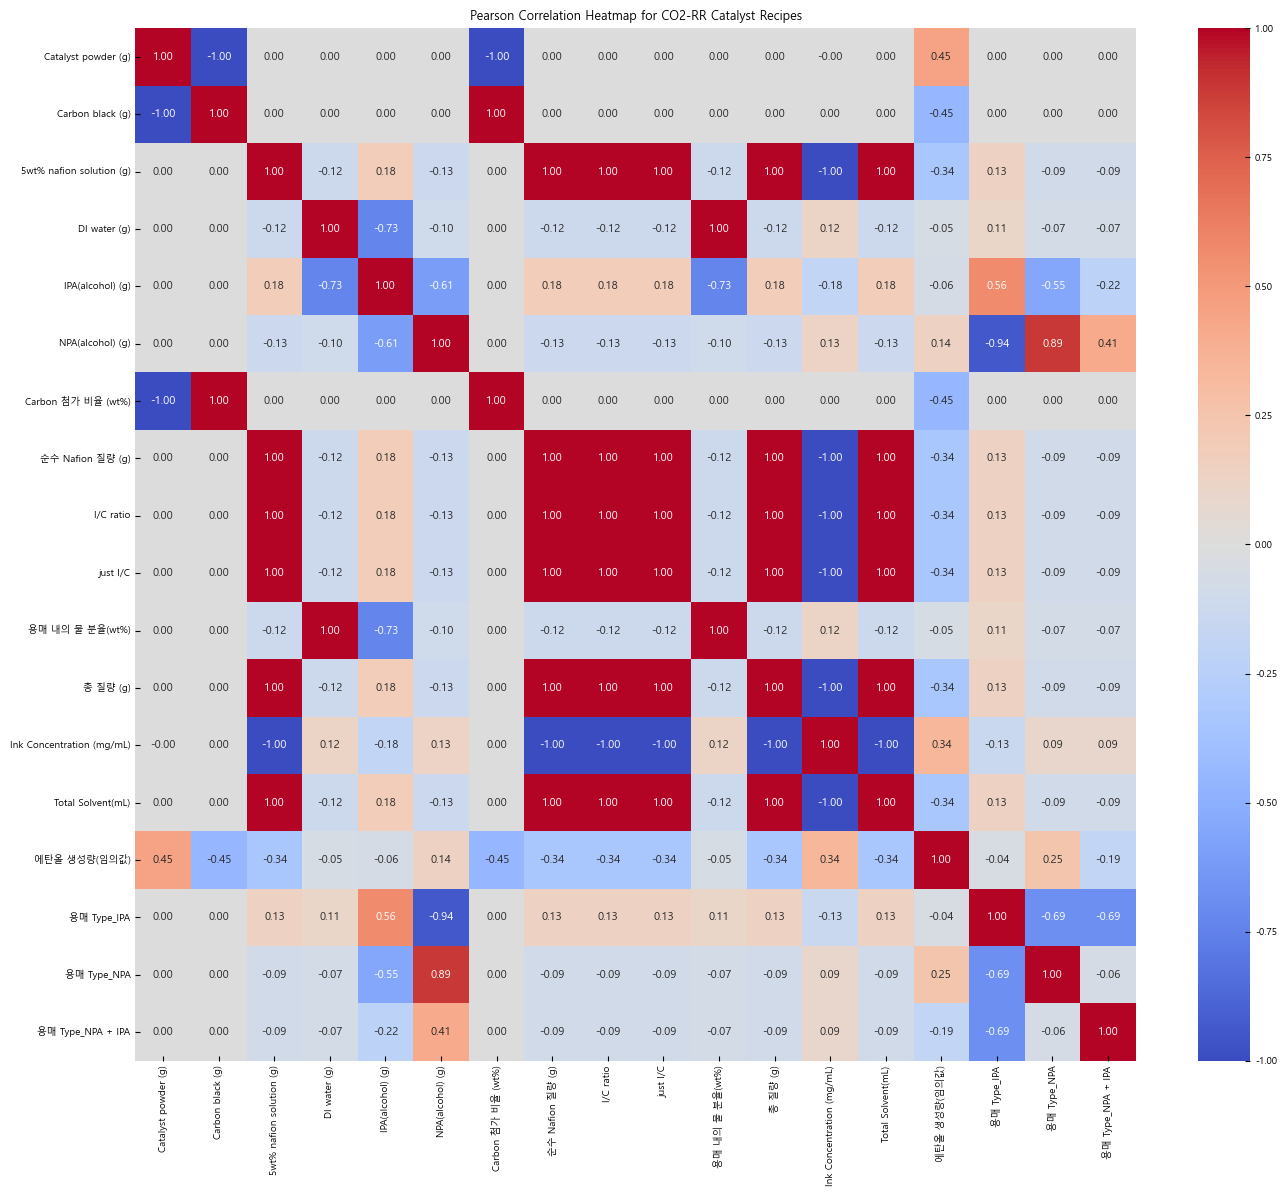

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'malgun.ttf' 

# matplotlib의 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

# 추가한 폰트의 고유 이름 추출
font_name = fm.FontProperties(fname=font_path).get_name()

# 추출한 폰트 이름을 전역 폰트로 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
# 1. 데이터 로드
# (주의: 파일명은 실제 저장하신 파일명과 일치시켜 주세요)
df = pd.read_csv('co2rr_catalyst_data.csv')

# --- [수정된 부분 1] ---
# '실험 조건' 열이 존재한다면, 이 열을 데이터의 인덱스(행 이름)로 설정하여 계산에서 제외합니다.
if '실험 조건' in df.columns:
    df.set_index('실험 조건', inplace=True)
# ---------------------

# 2. 불필요한 상수 변수(분산이 0인 열) 제거
df = df.loc[:, df.apply(pd.Series.nunique) != 1]

# 3. 범주형 변수(용매 Type) One-Hot Encoding 처리
if '용매 Type' in df.columns:
    df = pd.get_dummies(df, columns=['용매 Type'], dtype=int)

# 4. 피어슨 상관계수 행렬 계산
# --- [수정된 부분 2] ---
# numeric_only=True 인자를 추가하여 혹시 남아있을 수 있는 다른 문자열 데이터를 무시합니다.
corr_matrix = df.corr(method='pearson', numeric_only=True)
# ---------------------

# 5. 에탄올 생성량에 대한 상관계수만 내림차순으로 확인
# (주의: CSV 파일에 저장된 타겟 열 이름과 정확히 일치해야 합니다)
target_column = '에탄올 생성량(임의값)' 

if target_column in corr_matrix.columns:
    target_corr = corr_matrix[target_column].sort_values(ascending=False)
    print("--- 에탄올 생성량과의 상관계수 ---")
    print(target_corr)
else:
    print(f"'{target_column}' 열을 찾을 수 없습니다. 이름을 확인해주세요.")

# 6. 전체 변수 간의 상관관계 히트맵 시각화
plt.figure(figsize=(14, 12))
# 한글 폰트가 깨질 수 있으므로, matplotlib에 폰트 설정이 필요할 수 있습니다.
plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕 기준 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Pearson Correlation Heatmap for CO2-RR Catalyst Recipes')
plt.tight_layout()
plt.show()